# Clasificador de Reclamos del Call Center de BancoAndes

En este notebook construimos una base de datos sintética de los **últimos 18 meses** de reclamos del call center de **BancoAndes** y entrenamos un **clasificador de texto** que predice a qué área debería derivarse cada reclamo.

**Librerías**

[![Pandas](https://img.shields.io/badge/Pandas-150458?style=flat&logo=pandas&logoColor=white)](https://pandas.pydata.org/docs/)
[![re](https://img.shields.io/badge/re-built--in-3776AB?style=flat&logo=python&logoColor=white)](https://docs.python.org/3/library/re.html)
[![spaCy](https://img.shields.io/badge/spaCy-09A3D5?style=flat&logo=spacy&logoColor=white)](https://spacy.io/)
[![scikit-learn](https://img.shields.io/badge/scikit--learn-F7931E?style=flat&logo=scikit-learn&logoColor=white)](https://scikit-learn.org/stable/)
[![Matplotlib](https://img.shields.io/badge/Matplotlib-11557c?style=flat&logo=python&logoColor=white)](https://matplotlib.org/stable/index.html)
[![sentence-transformers](https://img.shields.io/badge/sentence--transformers-FF6F00?style=flat&logo=python&logoColor=white)](https://www.sbert.net/)

**Modelos y métodos**

[![spaCy TextCategorizer](https://img.shields.io/badge/spaCy_TextCategorizer-09A3D5?style=flat&logo=spacy&logoColor=white)](https://spacy.io/api/textcategorizer)
[![Word Embeddings](https://img.shields.io/badge/Word_Embeddings-2E8B57?style=flat&logo=python&logoColor=white)](https://spacy.io/usage/linguistic-features#vectors-similarity)
[![Sentence Embeddings](https://img.shields.io/badge/Sentence_Embeddings-6A0DAD?style=flat&logo=python&logoColor=white)](https://www.sbert.net/)
[![LogisticRegression](https://img.shields.io/badge/LogisticRegression-0078D4?style=flat&logo=python&logoColor=white)](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)

**Métricas**

[![Classification Report](https://img.shields.io/badge/Classification_Report-DC143C?style=flat&logo=python&logoColor=white)](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html)
[![Confusion Matrix](https://img.shields.io/badge/Confusion_Matrix-B8860B?style=flat&logo=python&logoColor=white)](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html)

---

In [1]:
import random
import re

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import spacy
from spacy.training import Example
from spacy.util import minibatch

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

## **2.** Carga y exploración de los datos

A partir de ahora trabajamos como si el CSV fuera nuestra base de datos de reclamos ya existente.

In [2]:
ruta_dataset = Path('../../datasets/archivos/reclamos/reclamos.csv')

df = pd.read_csv(ruta_dataset, parse_dates=['fecha'])
print(f'Total de reclamos: {len(df)}')
print(f'Rango de fechas: {df["fecha"].min().date()} a {df["fecha"].max().date()}')
df.sample(5, random_state=1)

Total de reclamos: 3914
Rango de fechas: 2025-03-01 a 2026-08-31


,id_reclamo,fecha,banco,area,texto
3197,3198,2026-05-23,BancoAndes,pre_venta,Una persona no autorizada generó cargos fraudu...
1227,1228,2025-08-22,BancoAndes,fraude_seguridad,No sé quién usó mi tarjeta de BancoAndes sin m...
891,892,2025-07-03,BancoAndes,ventas,Un representante de ventas de BancoAndes me co...
1670,1671,2025-10-22,BancoAndes,fraude_seguridad,Un tercero me contacto por phishing usando el ...
3458,3459,2026-06-28,BancoAndes,tecnologia,La&nbsp;banca en linea de BancoAndes se cierra...


## **2.1** Limpieza de texto con regex

Los reclamos vienen tal como los tipeó el cliente o los registró el ejecutivo del call center: con mayúsculas inconsistentes, HTML pegado (`&nbsp;`, `<p>`, `<br>`), firmas al final ("Enviado desde mi iPhone"), datos de contacto colados (RUT, teléfono, número de reclamo anterior), tildes faltantes, espacios/tabs irregulares y puntuación repetida (`!!!`, `???`).

Antes de vectorizar el texto para el modelo, lo normalizamos con expresiones regulares (`re`). Primero vemos algunos ejemplos con ruido:

In [6]:
patron_con_ruido = r'<|&nbsp;|Enviado desde|rut es|reclamo anterior|contactarme al|\t|  |!!|\?\?'
ejemplos_ruido = df[df['texto'].str.contains(patron_con_ruido, regex=True)].sample(10, random_state=42)

for texto in ejemplos_ruido['texto']:
    print(repr(texto))

'\tNadie en el  area comercial no  respeta el descuento  comercial  que me habian  prometido al  inicio y hasta ahora nadie me  ha dado una  solucion esta  semana.'
'BancoAndes de  BancoAndes  me esta cobrando  una multa que no  esta justificada  en  las ultimas semanas. Mi rut es 12.895.517-0.'
'<p>El área comercial de  BancoAndes me remitió  a distintas áreas sin darme  una respuesta clara  sin que nadie del  banco se haga responsable  el  mes  pasado.</p>'
'Nadie  en BancoAndes me deja sin respuesta  después de haber aceptado el  producto  en las  últimas  semanas.'
'Nadie en BancoAndes no da seguimiento a mi reclamo anterior sobre el mismo producto y hasta ahora nadie me ha dado una solución?!'
'Alguien vació parte de mi cuenta de BancoAndes y el banco no me ha devuelto el dinero lo cual me parece una falta de respeto hacia el cliente esta semana. Mi rut es 24.629.616-6.'
'\tEl  equipo de  cobranza  de BancoAndes me cobró  un  interés más alto del que  se había acordado sin que nad

In [7]:
def limpiar_texto(texto):
    # Todo lo que viene después del primer salto de línea es firma/pie de página
    texto = re.sub(r'\n.*', '', texto, flags=re.DOTALL)

    # Frases de contacto agregadas al final (RUT, teléfono, folio de reclamo anterior)
    texto = re.sub(r'\s*Mi rut es [\d.]+-[\dkK]\.', '', texto)
    texto = re.sub(r'\s*Pueden contactarme al \+56 9 \d{4} \d{4}\.', '', texto)
    texto = re.sub(r'\s*N° de reclamo anterior: RC-\d+\.', '', texto)

    # Tags HTML y entidades
    texto = re.sub(r'<[^>]+>|&nbsp;', ' ', texto)

    # Emojis
    texto = re.sub(r'[\U0001F300-\U0001FAFF☀-➿]', '', texto)

    # Puntuación repetida (!!!, ???, ..., ?!) -> un solo punto
    texto = re.sub(r'[!?.]{2,}', '.', texto)

    # Espacios/tabs múltiples
    texto = re.sub(r'\s+', ' ', texto).strip()

    return texto.lower()


def limpiar_banco(banco):
    return re.sub(r'(?i)\bbanco\s*andes\b', 'BancoAndes', banco.strip())


df['texto'] = df['texto'].apply(limpiar_texto)
df['banco'] = df['banco'].apply(limpiar_banco)

print('Bancos únicos tras la limpieza:', df['banco'].unique())
print()
print('Mismos ejemplos, ya limpios:')
for idx in ejemplos_ruido.index:
    print(repr(df.loc[idx, 'texto']))

Bancos únicos tras la limpieza: ['BancoAndes']

Mismos ejemplos, ya limpios:
'nadie en el area comercial no respeta el descuento comercial que me habian prometido al inicio y hasta ahora nadie me ha dado una solucion esta semana.'
'bancoandes de bancoandes me esta cobrando una multa que no esta justificada en las ultimas semanas.'
'el área comercial de bancoandes me remitió a distintas áreas sin darme una respuesta clara sin que nadie del banco se haga responsable el mes pasado.'
'nadie en bancoandes me deja sin respuesta después de haber aceptado el producto en las últimas semanas.'
'nadie en bancoandes no da seguimiento a mi reclamo anterior sobre el mismo producto y hasta ahora nadie me ha dado una solución.'
'alguien vació parte de mi cuenta de bancoandes y el banco no me ha devuelto el dinero lo cual me parece una falta de respeto hacia el cliente esta semana.'
'el equipo de cobranza de bancoandes me cobró un interés más alto del que se había acordado sin que nadie del banco se ha

In [8]:
df['area'].value_counts()

area
tecnologia          731
cobranza            686
post_venta          594
ventas              582
fraude_seguridad    474
comercial           435
pre_venta           412
Name: count, dtype: int64

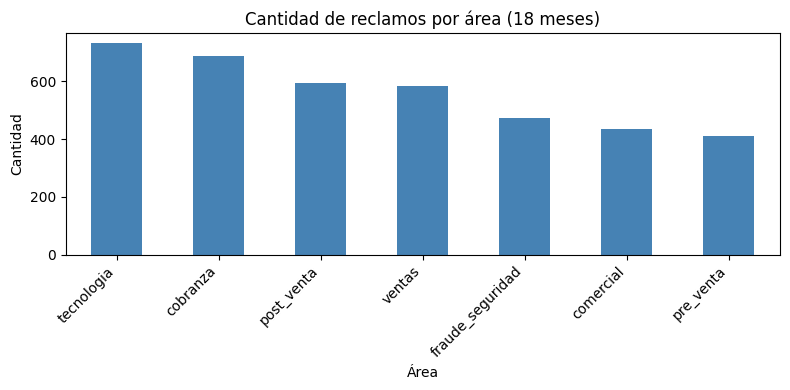

In [9]:
df['area'].value_counts().plot(kind='bar', figsize=(8, 4), color='steelblue')
plt.title('Cantidad de reclamos por área (18 meses)')
plt.ylabel('Cantidad')
plt.xlabel('Área')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Evolución mensual de reclamos

Como tenemos la fecha de cada reclamo, podemos ver cómo evoluciona el volumen total mes a mes, y también cómo se distribuyen las áreas en el tiempo.

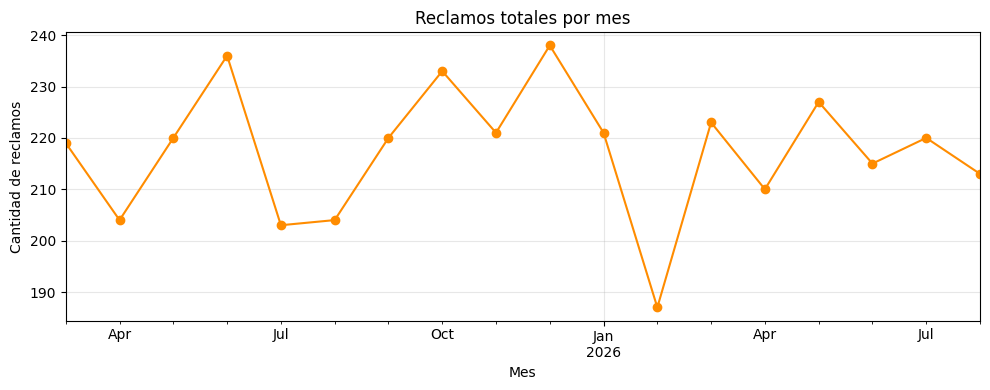

In [10]:
reclamos_por_mes = df.set_index('fecha').resample('MS').size()

reclamos_por_mes.plot(kind='line', marker='o', figsize=(10, 4), color='darkorange')
plt.title('Reclamos totales por mes')
plt.ylabel('Cantidad de reclamos')
plt.xlabel('Mes')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

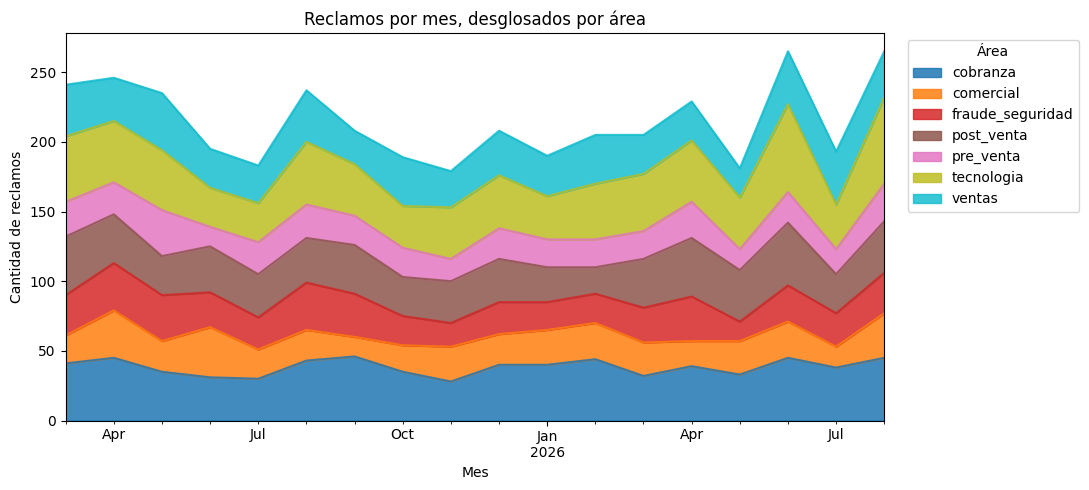

In [ ]:
reclamos_area_mes = df.groupby([df['fecha'].dt.to_period('M'), 'area']).size().unstack(fill_value=0)
reclamos_area_mes.index = reclamos_area_mes.index.to_timestamp()

reclamos_area_mes.plot(kind='area', stacked=True, figsize=(11, 5), colormap='tab10', alpha=0.85)
plt.title('Reclamos por mes, desglosados por área')
plt.ylabel('Cantidad de reclamos')
plt.xlabel('Mes')
plt.legend(title='Área', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## **2.2** Longitud de los reclamos

Antes de entrenar cualquier modelo conviene entender cómo son los textos que va a ver: si son muy cortos, muy largos, o si hay diferencias de largo entre áreas (por ejemplo, reclamos de fraude podrían ser más detallados que uno de ventas).

count    3914.000000
mean       19.831375
std         4.729772
min         7.000000
25%        16.000000
50%        20.000000
75%        23.000000
max        35.000000
Name: n_palabras, dtype: float64


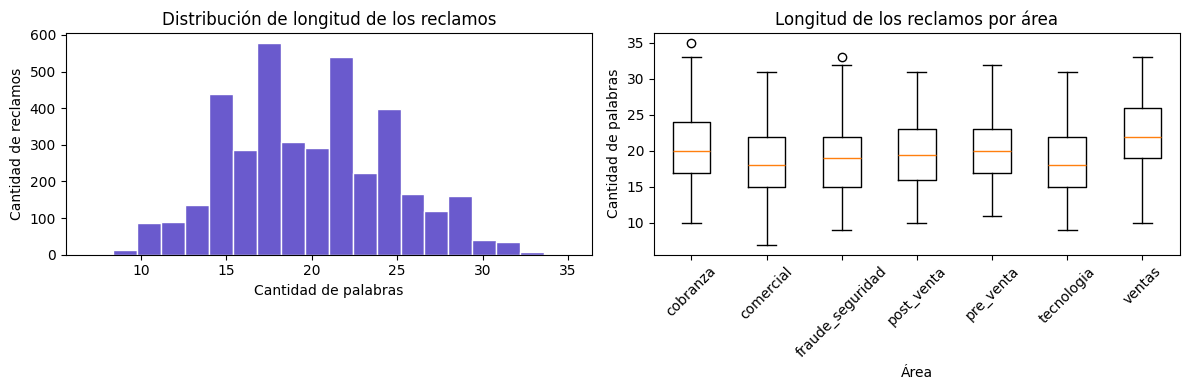

In [11]:
areas_lista = sorted(df['area'].unique())

df['n_palabras'] = df['texto'].str.split().str.len()

print(df['n_palabras'].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['n_palabras'], bins=20, color='slateblue', edgecolor='white')
axes[0].set_title('Distribución de longitud de los reclamos')
axes[0].set_xlabel('Cantidad de palabras')
axes[0].set_ylabel('Cantidad de reclamos')

datos_por_area = [df.loc[df['area'] == area, 'n_palabras'] for area in areas_lista]
axes[1].boxplot(datos_por_area, labels=areas_lista)
axes[1].set_title('Longitud de los reclamos por área')
axes[1].set_xlabel('Área')
axes[1].set_ylabel('Cantidad de palabras')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## **2.3** Palabras más frecuentes por área

Para tener una primera intuición de qué vocabulario distingue a cada área —antes de entrenar ningún modelo— contamos las palabras más frecuentes de cada una, descartando palabras muy comunes que no aportan información (**stopwords** como "el", "de", "que", y también "bancoandes", que aparece en casi todos los reclamos).

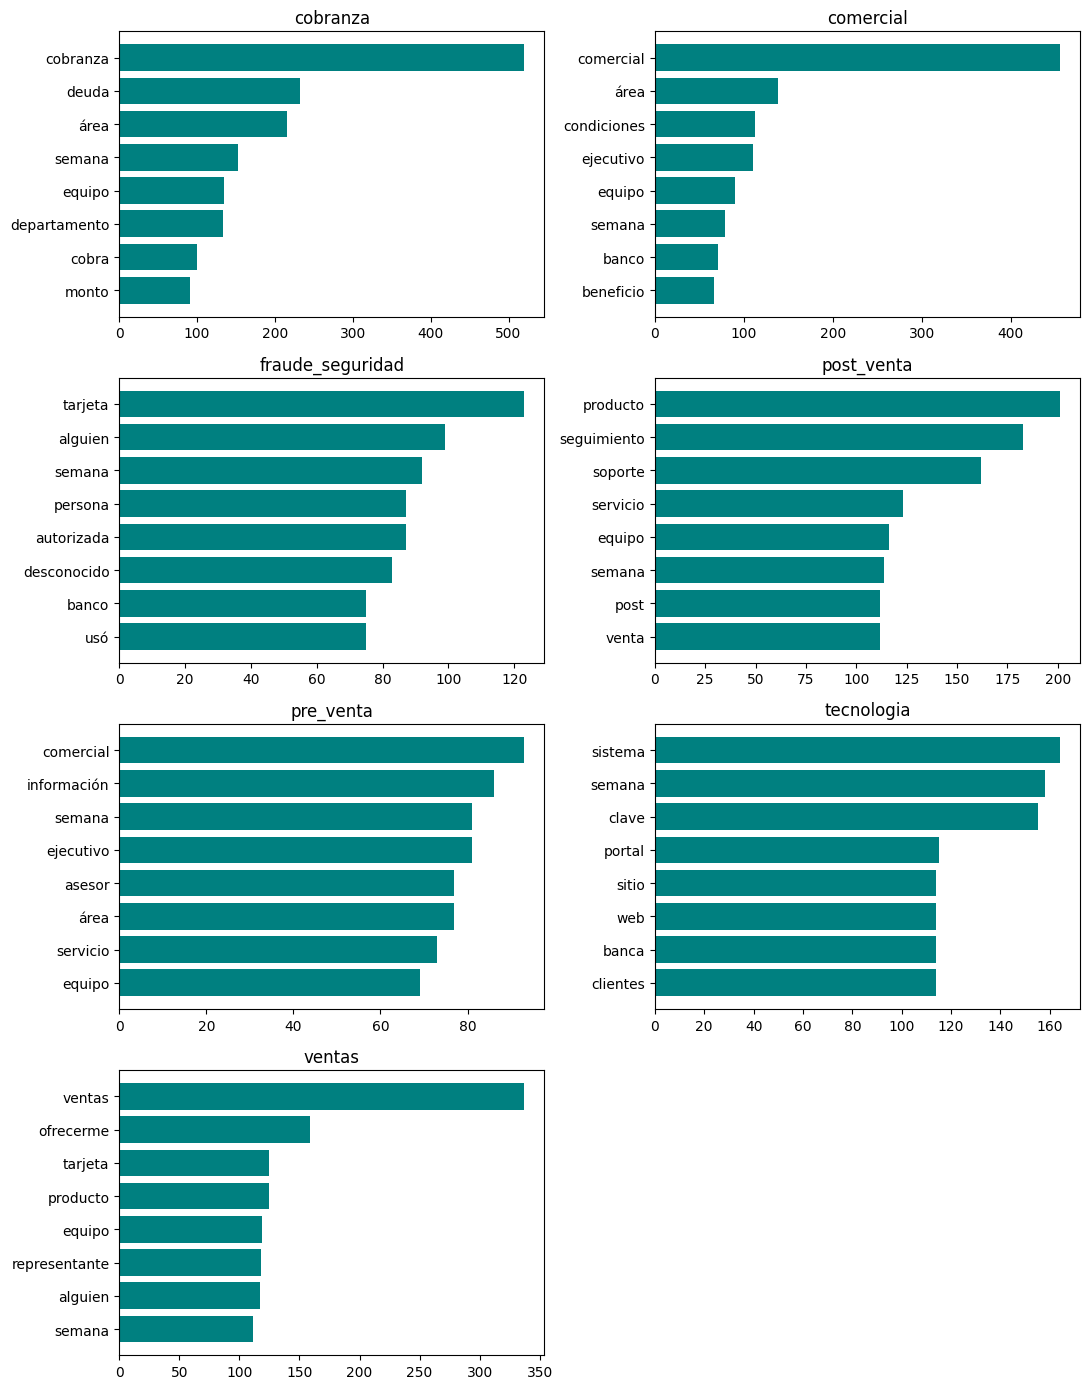

In [12]:
from collections import Counter
from spacy.lang.es.stop_words import STOP_WORDS

palabras_ignorar = STOP_WORDS | {'bancoandes'}


def palabras_frecuentes(textos, top=8):
    contador = Counter()
    for texto in textos:
        palabras = re.findall(r'\b[a-zñáéíóú]+\b', texto)
        contador.update(p for p in palabras if p not in palabras_ignorar and len(p) > 2)
    return contador.most_common(top)


fig, axes = plt.subplots(4, 2, figsize=(11, 14))
axes = axes.flatten()

for ax, area in zip(axes, areas_lista):
    top_palabras = palabras_frecuentes(df.loc[df['area'] == area, 'texto'])
    palabras, frecuencias = zip(*top_palabras)
    ax.barh(palabras[::-1], frecuencias[::-1], color='teal')
    ax.set_title(area)

for ax in axes[len(areas_lista):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

## **2.4** Reclamos duplicados

A propósito, esta base **no tiene texto exactamente repetido**: cada reclamo fue redactado de forma distinta, incluso cuando dos clientes reportan el mismo tipo de problema. Esto es importante porque, si hubiera frases idénticas repartidas entre entrenamiento y prueba, el modelo podría "memorizar" esas frases exactas en vez de aprender a generalizar — un problema real llamado **fuga de datos**, que revisamos igual como buena práctica en la sección 4.

In [13]:
n_duplicados = df['texto'].duplicated().sum()
pct_duplicados = n_duplicados / len(df) * 100

print(f'Reclamos con texto exactamente repetido: {n_duplicados} de {len(df)} ({pct_duplicados:.1f}%)')
print()
print('Textos que más se repiten:')
print(df['texto'].value_counts().head(5))

Reclamos con texto exactamente repetido: 0 de 3914 (0.0%)

Textos que más se repiten:
texto
bancoandes de bancoandes no acepta renegociar mi deuda en condiciones razonables.                                                                     1
una persona no autorizada accedió a mi cuenta de bancoandes sin que yo lo autorizara y esto ya me tiene bastante molesto ayer.                        1
el portal de clientes de bancoandes no permite descargar mis comprobantes de pago lo cual me parece una falta de respeto hacia el cliente.            1
bancoandes de bancoandes sigue enviándome cartas de cobro por una deuda pagada sin que nadie del banco se haga responsable en las últimas semanas.    1
alguien del equipo de ventas de bancoandes me contacto fuera de horario para ofrecerme una tarjeta nueva y no encuentro como resolverlo.              1
Name: count, dtype: int64


## **3.** Partición temporal: muestra vs. fuera de muestra

En vez de mezclar todos los reclamos al azar, respetamos la dimensión temporal:

- **En muestra (`df_muestra`)**: los primeros **12 meses** de historia. Todo el desarrollo del modelo (entrenamiento, comparación de particiones) se hace únicamente con estos datos.
- **Fuera de muestra (`df_fuera_muestra`)**: los **últimos 6 meses**. Estos reclamos **no se tocan** durante el entrenamiento ni la selección del modelo — se usan al final, una sola vez, para simular cómo se comportaría el modelo con reclamos futuros que nunca vio.

In [14]:
fecha_corte = df['fecha'].max() - pd.DateOffset(months=6)

df_muestra = df[df['fecha'] < fecha_corte].copy()
df_fuera_muestra = df[df['fecha'] >= fecha_corte].copy()

print(f'Fecha de corte: {fecha_corte.date()}')
print(f'En muestra (primeros 12 meses):   {len(df_muestra)} reclamos, de {df_muestra["fecha"].min().date()} a {df_muestra["fecha"].max().date()}')
print(f'Fuera de muestra (últimos 6 meses): {len(df_fuera_muestra)} reclamos, de {df_fuera_muestra["fecha"].min().date()} a {df_fuera_muestra["fecha"].max().date()}')

Fecha de corte: 2026-02-28
En muestra (primeros 12 meses):   2601 reclamos, de 2025-03-01 a 2026-02-27
Fuera de muestra (últimos 6 meses): 1313 reclamos, de 2026-02-28 a 2026-08-31


## **4.** Train/test split dentro de la muestra

Dentro de `df_muestra` (los 12 meses) hacemos un split 80% / 20%, estratificado por área, para entrenar y evaluar el modelo antes de fijarlo como definitivo.

**Nota sobre fuga de datos (data leakage):** en la sección 2.4 confirmamos que no hay texto duplicado en la base, así que un split al azar acá es seguro — ninguna frase exacta puede quedar repartida entre train y test. Si estuvieras trabajando con una base real donde el mismo texto (o un texto casi idéntico) se repite muchas veces, tendrías que usar un **split por grupos** (`GroupShuffleSplit`, agrupando por texto) para que esas repeticiones queden siempre del mismo lado; si no, el modelo podría memorizar frases en vez de generalizar, y el reporte saldría "perfecto" sin que eso signifique que aprendió algo útil.

In [15]:
assert df_muestra['texto'].duplicated().sum() == 0, 'hay texto duplicado, no usar split al azar sin agrupar'

X_train, X_test, y_train, y_test = train_test_split(
    df_muestra['texto'], df_muestra['area'],
    test_size=0.2, random_state=42, stratify=df_muestra['area']
)

print(f'Entrenamiento: {len(X_train)} reclamos')
print(f'Prueba: {len(X_test)} reclamos')

Entrenamiento: 2080 reclamos
Prueba: 521 reclamos


### ¿Qué hace el spaCy `TextCategorizer`? (explicado simple)

**¿Qué busca el algoritmo?** Para cada reclamo, el modelo calcula una probabilidad para cada una de las 7 áreas (todas suman 1 entre sí) y busca que la probabilidad más alta caiga justo en el área correcta. Entrenar significa ir ajustando un montón de números internos (parámetros) para que, en promedio, ese error de predicción sea cada vez más chico — igual que un niño que va afinando su intuición a punta de ensayo y error.

**Ejemplo concreto:** el reclamo *"Me cobraron dos veces la misma cuota este mes"* tiene etiqueta real `cobranza`. Al arrancar el entrenamiento (con pesos al azar), el modelo podría predecir algo parecido a esto:

| Área | Probabilidad (antes de entrenar) |
|---|---|
| cobranza | 0.16 |
| fraude_seguridad | 0.15 |
| tecnologia | 0.14 |
| ventas | 0.14 |
| post_venta | 0.14 |
| comercial | 0.14 |
| pre_venta | 0.13 |

Como la respuesta correcta era `cobranza`, el modelo ajusta un poquito sus pesos para que, la próxima vez que vea palabras como "cobraron" o "cuota", suba la probabilidad de `cobranza` y baje el resto. Repitiendo esto miles de veces con miles de reclamos distintos, termina prediciendo algo como `cobranza: 0.91`, `fraude_seguridad: 0.04`, ... — sin que nadie le haya dicho explícitamente "busca la palabra 'cobraron'", el modelo lo descubrió solo.

In [ ]:
def entrenar_textcat(textos, etiquetas, n_iter=15, batch_size=16, seed=42):
    areas_unicas = sorted(set(etiquetas))

    nlp = spacy.blank('es')
    textcat = nlp.add_pipe('textcat')
    for area in areas_unicas:
        textcat.add_label(area)

    ejemplos = []
    for texto, etiqueta in zip(textos, etiquetas):
        doc = nlp.make_doc(texto)
        cats = {area: (1.0 if area == etiqueta else 0.0) for area in areas_unicas}
        ejemplos.append(Example.from_dict(doc, {'cats': cats}))

    random.seed(seed)
    nlp.initialize(lambda: ejemplos)

    for epoca in range(n_iter):
        random.shuffle(ejemplos)
        losses = {}
        for batch in minibatch(ejemplos, size=batch_size):
            nlp.update(batch, losses=losses)
        if (epoca + 1) % 5 == 0 or epoca == n_iter - 1:
            print(f'Época {epoca + 1}/{n_iter} - loss: {losses["textcat"]:.4f}')

    return nlp, areas_unicas


def predecir_textcat(nlp, textos, con_confianza=False):
    resultados = [nlp(texto).cats for texto in textos]
    etiquetas_predichas = [max(r.items(), key=lambda kv: kv[1])[0] for r in resultados]
    if con_confianza:
        confianzas = [max(r.values()) for r in resultados]
        return etiquetas_predichas, confianzas
    return etiquetas_predichas


nlp_textcat, areas_train = entrenar_textcat(X_train.tolist(), y_train.tolist())

y_pred = predecir_textcat(nlp_textcat, X_test.tolist())
print(classification_report(y_test, y_pred))

Época 5/15 - loss: 1.9540
Época 10/15 - loss: 1.9148
Época 15/15 - loss: 1.9345
                  precision    recall  f1-score   support

        cobranza       0.98      0.97      0.97        91
       comercial       0.93      0.95      0.94        57
fraude_seguridad       0.96      0.89      0.92        62
      post_venta       0.95      0.95      0.95        74
       pre_venta       0.92      0.91      0.91        53
      tecnologia       0.97      1.00      0.98        89
          ventas       0.94      0.97      0.95        76

        accuracy                           0.95       502
       macro avg       0.95      0.95      0.95       502
    weighted avg       0.95      0.95      0.95       502



### Comparación: spaCy TextCategorizer vs. Regresión logística sobre embeddings de palabras

Ahora comparamos el TextCategorizer contra un enfoque más clásico, para ver si vale la pena la complejidad extra de una red neuronal.

**La idea, en simple:** cada palabra en español ya tiene, gracias al modelo `es_core_news_md` de spaCy, una especie de "tarjeta secreta" con 300 números que resume su significado — esa tarjeta se aprendió de antemano, leyendo muchísimo texto en español. Para representar un reclamo completo, promediamos las tarjetas de todas sus palabras, como mezclar los colores de varios lápices para sacar un color promedio.

**¿Qué busca el algoritmo?** La `LogisticRegression` busca encontrar los números (pesos) que, multiplicados por ese vector promedio de 300 números, separen lo mejor posible los reclamos de las 7 áreas — es decir, busca trazar "líneas divisorias" en ese espacio de 300 dimensiones, de forma que los reclamos de una misma área queden agrupados de un mismo lado.

**Ejemplo simplificado** (con vectores de solo 2 números en vez de 300, para poder imaginarlo en un plano):

| Palabra | Vector (simplificado) |
|---|---|
| tarjeta | (0.8, 0.1) |
| bloqueada | (0.7, 0.3) |
| cobraron | (-0.2, 0.9) |
| cuota | (-0.3, 0.8) |

El reclamo "tarjeta bloqueada" se representa como el promedio de sus dos palabras: `((0.8+0.7)/2, (0.1+0.3)/2) = (0.75, 0.2)`. El reclamo "cobraron cuota" queda en `(-0.25, 0.85)` — bastante lejos del anterior en ese plano. La regresión logística aprende una línea recta que separe estos dos grupos de puntos, y para un reclamo nuevo simplemente se fija de qué lado de la línea cae su vector.

Si el reporte de ambos modelos da muy alto, no asumas que "funcionó buenísimo": esta base tiene vocabulario bastante distintivo por área (ej. "tarjeta bloqueada" vs "cobro duplicado"), lo que hace el problema más fácil de separar que reclamos reales de un call center (donde el lenguaje es más ambiguo y ruidoso, y además suele haber texto repetido o casi repetido). Antes de confiar en un resultado muy alto conviene revisar la matriz de confusión (sección 5) y el tamaño de cada clase (sección 2) — no solo el accuracy.

In [ ]:
import numpy as np
from sklearn.linear_model import LogisticRegression

# 1. Cargar el modelo de spaCy
# Nota: si te falta este modelo, puedes descargarlo ejecutando: !python -m spacy download es_core_news_md
nlp_es = spacy.load("es_core_news_md")

# 2. Convertir los textos en embeddings promediados
def get_embeddings(textos):
    return np.array([doc.vector for doc in nlp_es.pipe(textos)])

print("Extrayendo embeddings para entrenamiento...")
X_train_spacy = get_embeddings(X_train)

print("Extrayendo embeddings para prueba...")
X_test_spacy = get_embeddings(X_test)

# 3. Entrenar el clasificador
clf_spacy = LogisticRegression(max_iter=1000)
clf_spacy.fit(X_train_spacy, y_train)

# 4. Predicción y evaluación
y_pred_spacy = clf_spacy.predict(X_test_spacy)

print('=== spaCy TextCategorizer ===')
print(classification_report(y_test, y_pred))

print('=== Regresión logística (spaCy Embeddings) ===')
print(classification_report(y_test, y_pred_spacy))

Extrayendo embeddings para entrenamiento...
Extrayendo embeddings para prueba...
=== spaCy TextCategorizer ===
                  precision    recall  f1-score   support

        cobranza       0.98      0.97      0.97        91
       comercial       0.93      0.95      0.94        57
fraude_seguridad       0.96      0.89      0.92        62
      post_venta       0.95      0.95      0.95        74
       pre_venta       0.92      0.91      0.91        53
      tecnologia       0.97      1.00      0.98        89
          ventas       0.94      0.97      0.95        76

        accuracy                           0.95       502
       macro avg       0.95      0.95      0.95       502
    weighted avg       0.95      0.95      0.95       502

=== Regresión logística (spaCy Embeddings) ===
                  precision    recall  f1-score   support

        cobranza       0.98      0.97      0.97        91
       comercial       0.93      0.95      0.94        57
fraude_seguridad       0.9

### Un enfoque más moderno: embeddings de oraciones completas

El método anterior promedia los vectores de cada palabra por separado — funciona bien, pero se pierden matices: "tarjeta bloqueada" y "no puedo usar mi tarjeta" comparten pocas palabras exactas, y promediar palabra por palabra no siempre capta que significan casi lo mismo, porque nunca se mira la oración como un todo.

**¿Qué busca el algoritmo?** En vez de promediar palabra por palabra, un modelo de *sentence embeddings* ya leyó millones de oraciones en muchos idiomas y aprendió a asignarle a cada oración completa un único vector de 384 números, buscando que oraciones con significado parecido —aunque usen palabras distintas— queden con vectores cercanos entre sí (alta similitud), y oraciones con significado distinto queden lejos.

**Ejemplo concreto:** más abajo tomamos tres frases —dos sobre problemas con la tarjeta y una sobre un préstamo— y medimos qué tan "cerca" quedan sus vectores usando **similitud de coseno** (1 = significan lo mismo, 0 = no tienen relación). Vas a ver que las dos frases de la tarjeta quedan con similitud alta (~0.64) aunque casi no comparten palabras, mientras que la del préstamo queda bien más lejos de ambas (~0.15–0.36).

Vamos a usar [`sentence-transformers`](https://www.sbert.net/), una librería que permite obtener estos embeddings con modelos livianos y gratuitos que corren en la propia notebook (sin llamar a ninguna API paga). Usamos `paraphrase-multilingual-MiniLM-L12-v2`, un modelo entrenado para funcionar bien en español (y otros idiomas).

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

modelo_embeddings = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

frases_ejemplo = [
    'Mi tarjeta fue bloqueada sin avisarme',
    'No puedo usar mi tarjeta de crédito',
    'Quiero información sobre un préstamo nuevo',
]

embeddings_ejemplo = modelo_embeddings.encode(frases_ejemplo)
print(f'Cada frase se representa con un vector de {embeddings_ejemplo.shape[1]} números')

similitud = cosine_similarity(embeddings_ejemplo)
pd.DataFrame(similitud, index=frases_ejemplo, columns=frases_ejemplo).round(2)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Cada frase se representa con un vector de 384 números


,Mi tarjeta fue bloqueada sin avisarme,No puedo usar mi tarjeta de crédito,Quiero información sobre un préstamo nuevo
Mi tarjeta fue bloqueada sin avisarme,1.00,0.64,0.15
No puedo usar mi tarjeta de crédito,0.64,1.00,0.36
Quiero información sobre un préstamo nuevo,0.15,0.36,1.00


Como se ve arriba, las dos frases sobre problemas con la tarjeta quedan con alta similitud entre sí (aunque no comparten casi palabras), y bajan mucho respecto a la frase sobre préstamos. Eso es justo lo que el promedio simple de vectores por palabra (sección anterior) capta peor: al leer la oración completa en vez de promediar palabra por palabra, el modelo de sentence-transformers entiende mejor el significado global, no solo el vocabulario compartido.

Ahora usamos estos embeddings como features para el mismo problema de clasificación: convertimos cada reclamo del split de entrenamiento/prueba en un vector de embedding de oración, y entrenamos una `LogisticRegression` sobre esos vectores.

In [ ]:
from sklearn.linear_model import LogisticRegression

X_train_emb = modelo_embeddings.encode(X_train.tolist(), show_progress_bar=True)
X_test_emb = modelo_embeddings.encode(X_test.tolist(), show_progress_bar=True)

clf_emb = LogisticRegression(max_iter=1000)
clf_emb.fit(X_train_emb, y_train)

y_pred_emb = clf_emb.predict(X_test_emb)

print('=== Regresión logística sobre embeddings (sentence-transformers) ===')
print(classification_report(y_test, y_pred_emb))

Batches:   0%|          | 0/63 [00:00<?, ?it/s]

Batches:   0%|          | 0/16 [00:00<?, ?it/s]

=== Regresión logística sobre embeddings (sentence-transformers) ===
                  precision    recall  f1-score   support

        cobranza       0.96      0.97      0.96        91
       comercial       0.93      0.95      0.94        57
fraude_seguridad       0.96      0.85      0.91        62
      post_venta       0.95      0.97      0.96        74
       pre_venta       0.96      0.91      0.93        53
      tecnologia       0.97      1.00      0.98        89
          ventas       0.94      0.97      0.95        76

        accuracy                           0.95       502
       macro avg       0.95      0.95      0.95       502
    weighted avg       0.95      0.95      0.95       502



## **5.** Modelo final y evaluación fuera de muestra

Entrenamos el modelo final usando **todo** `df_muestra` (los 12 meses) y lo evaluamos contra `df_fuera_muestra` (los últimos 6 meses), que el modelo nunca vio. Esta es la evaluación más realista, porque simula aplicar el modelo a reclamos futuros.

In [ ]:
nlp_final, areas_finales = entrenar_textcat(df_muestra['texto'].tolist(), df_muestra['area'].tolist())

y_pred_fuera_muestra, confianza_fuera_muestra = predecir_textcat(
    nlp_final, df_fuera_muestra['texto'].tolist(), con_confianza=True
)

print(classification_report(df_fuera_muestra['area'], y_pred_fuera_muestra))

Época 5/15 - loss: 2.3331
Época 10/15 - loss: 2.3251
Época 15/15 - loss: 2.3291
                  precision    recall  f1-score   support

        cobranza       0.96      0.95      0.96       234
       comercial       0.97      0.96      0.96       140
fraude_seguridad       0.96      0.95      0.96       151
      post_venta       0.97      0.94      0.96       225
       pre_venta       0.96      0.93      0.94       128
      tecnologia       0.94      0.97      0.96       281
          ventas       0.94      0.98      0.96       187

        accuracy                           0.96      1346
       macro avg       0.96      0.95      0.96      1346
    weighted avg       0.96      0.96      0.96      1346



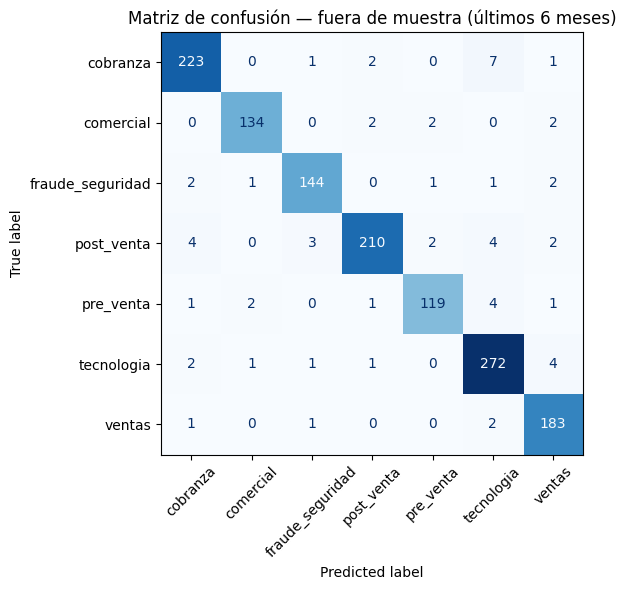

In [ ]:
areas = sorted(df['area'].unique())
cm = confusion_matrix(df_fuera_muestra['area'], y_pred_fuera_muestra, labels=areas)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=areas)
disp.plot(ax=ax, xticks_rotation=45, cmap='Blues', colorbar=False)
plt.title('Matriz de confusión — fuera de muestra (últimos 6 meses)')
plt.tight_layout()
plt.show()

## **6.** Reclamos más representativos por área

`textcat` es una red neuronal: a diferencia de Naive Bayes, no tiene una probabilidad por palabra que se pueda leer directamente (`feature_log_prob_`). En su lugar, inspeccionamos, para cada área, los reclamos que el modelo clasificó con **mayor confianza** — una forma indirecta de ver qué está aprendiendo a reconocer como típico de cada área.

In [ ]:
df_ejemplos = df_fuera_muestra.copy()
df_ejemplos['area_predicha'] = y_pred_fuera_muestra
df_ejemplos['confianza'] = confianza_fuera_muestra

for area in areas_finales:
    top = df_ejemplos[df_ejemplos['area_predicha'] == area].sort_values('confianza', ascending=False).head(3)
    print(f'\n=== {area} ===')
    for _, fila in top.iterrows():
        print(f'  ({fila["confianza"]:.2f}) {fila["texto"]}')


=== cobranza ===
  (1.00) recibi llamadas de cobranza de bancoandes de forma agresiva y fuera de horario.
  (1.00) recibi llamadas de cobranza de bancoandes de forma agresiva y fuera de horario.
  (1.00) recibi llamadas de cobranza de bancoandes de forma agresiva y fuera de horario.

=== comercial ===
  (1.00) solicite una repactacion de mi deuda en bancoandes y el proceso esta detenido.
  (1.00) solicite una repactacion de mi deuda en bancoandes y el proceso esta detenido.
  (1.00) solicite una repactacion de mi deuda en bancoandes y el proceso esta detenido.

=== fraude_seguridad ===
  (1.00) detecte cargos no reconocidos en mi tarjeta de bancoandes y nadie me da solucion.
  (1.00) detecte cargos no reconocidos en mi tarjeta de bancoandes y nadie me da solucion.
  (1.00) detecte cargos no reconocidos en mi tarjeta de bancoandes y nadie me da solucion.

=== post_venta ===
  (0.99) despues de contratar el credito hipotecario, bancoandes no me da soporte con mis dudas.
  (0.99) despues

## **7.** Aplicar el modelo final a reclamos nuevos (sin etiquetar)

Por último, cargamos una base de datos separada de reclamos **sin la columna `area`** — reclamos "nuevos" que llegaron al call center y todavía no fueron clasificados — y usamos el modelo final para asignarles una categoría automáticamente.

In [ ]:
ruta_sin_etiquetar = Path('../../datasets/archivos/reclamos/reclamos_sin_etiquetar.csv')
df_nuevos = pd.read_csv(ruta_sin_etiquetar, parse_dates=['fecha'])

print(f'Reclamos sin etiquetar: {len(df_nuevos)}')
df_nuevos.head()

Reclamos sin etiquetar: 150


,id_reclamo,fecha,banco,texto
0,1,2026-09-01,BancoAndes,El sitio web de BancoAndes lleva dos días caíd...
1,2,2026-09-01,BancoAndes,Me vendieron un seguro en BancoAndes sin expli...
2,3,2026-09-01,BancoAndes,No puedo ingresar a la banca en línea de Banco...
3,4,2026-09-01,BancoAndes,Solicité una cotización de crédito hipotecario...
4,5,2026-09-01,BancoAndes,BancoAndes no me ofrece una mejor tasa a pesar...


In [ ]:
df_nuevos['area_predicha'] = predecir_textcat(nlp_final, df_nuevos['texto'].tolist())
df_nuevos[['fecha', 'texto', 'area_predicha']].head(10)

,fecha,texto,area_predicha
0,2026-09-01,El sitio web de BancoAndes lleva dos días caíd...,tecnologia
1,2026-09-01,Me vendieron un seguro en BancoAndes sin expli...,ventas
2,2026-09-01,No puedo ingresar a la banca en línea de Banco...,tecnologia
3,2026-09-01,Solicité una cotización de crédito hipotecario...,pre_venta
4,2026-09-01,BancoAndes no me ofrece una mejor tasa a pesar...,comercial
5,2026-09-01,Me cobran una multa de BancoAndes que no está ...,cobranza
6,2026-09-01,El sitio web de BancoAndes lleva dos días caíd...,tecnologia
7,2026-09-01,BancoAndes no me ha devuelto el dinero de una ...,fraude_seguridad
8,2026-09-01,Solicité una cotización de crédito hipotecario...,pre_venta
9,2026-09-02,BancoAndes no ha activado el beneficio que ven...,post_venta


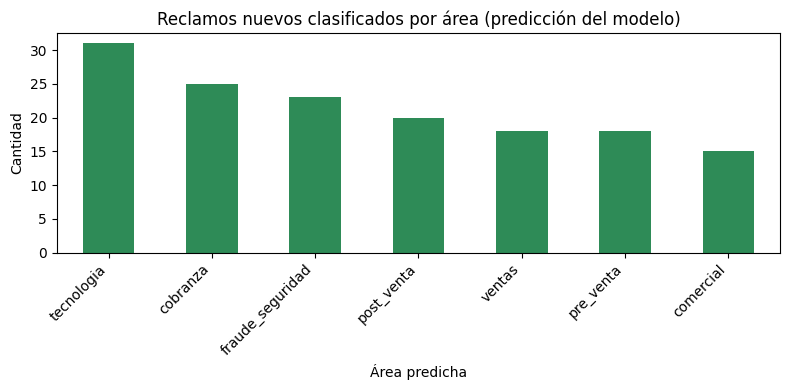

In [ ]:
df_nuevos['area_predicha'].value_counts().plot(kind='bar', figsize=(8, 4), color='seagreen')
plt.title('Reclamos nuevos clasificados por área (predicción del modelo)')
plt.ylabel('Cantidad')
plt.xlabel('Área predicha')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()